# wCDM MCMC: $H_0$, $w$, $\Omega_m$

Flat universe assumed ($\Omega_k = 0$). Instead of a cosmological constant, dark energy has
a constant equation-of-state parameter $w$ (so $w=-1$ reduces to $\Lambda$CDM):

$$\rho_{DE}(z) \propto (1+z)^{3(1+w)}, \qquad \Omega_\Lambda = 1 - \Omega_m \text{ (today)}$$

Free parameters sampled by MCMC: $H_0$, $w$, and $\Omega_m$.

In [1]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [2]:
import os

# every sampler cell below checks this directory for a saved chain first and
# loads it instead of re-running - restarting the kernel no longer means
# re-sampling for 50k+ iterations just to tweak a plot downstream.
# Delete the relevant .csv/.npz/.h5 file here (or flip force_rerun=True in a
# sampler cell) if you actually want to redo a run from scratch.
cache_dir = "mcmc_cache_wcdm"
os.makedirs(cache_dir, exist_ok=True)

In [3]:
# fiducial parameters (starting point / sanity-check values, not fixed priors)
h = 0.71
Omega_m = 0.3
w = -1.0                 # fiducial: cosmological constant limit
Omega_Lambda = 1 - Omega_m   # flatness, evaluated today

H0 = 100 * h            # km/s/Mpc
c = 299792.458          # speed of light, km/s

## Distances in a Flat wCDM Universe

$$H(z) = H_0\sqrt{\Omega_m (1+z)^3 + (1-\Omega_m)(1+z)^{3(1+w)}}$$

Flat geometry means the transverse comoving distance equals the comoving distance directly.

In [4]:
# Hubble parameter with a dark-energy equation-of-state term w
def hubble_param(z, H0_val, omega_m_val, w_val):
    de_term = (1 - omega_m_val) * (1 + z)**(3 * (1 + w_val))
    return H0_val * np.sqrt(omega_m_val * (1 + z)**3 + de_term)

def comoving_integrand(z, H0_val, omega_m_val, w_val):
    return c / hubble_param(z, H0_val, omega_m_val, w_val)

def comoving_distance_wcdm(z, H0_val, omega_m_val, w_val):
    D_c, err = integrate.quad(comoving_integrand, 0, z, args=(H0_val, omega_m_val, w_val))
    return D_c

def luminosity_distance_wcdm(z, H0_val, omega_m_val, w_val):
    D_c = comoving_distance_wcdm(z, H0_val, omega_m_val, w_val)
    return D_c * (1 + z)

def distance_modulus_wcdm(z, H0_val, omega_m_val, w_val):
    D_L = luminosity_distance_wcdm(z, H0_val, omega_m_val, w_val)
    return 5 * np.log10(D_L) + 25

In [5]:
# sanity check at a single redshift, fiducial parameters
z_test = 2
D_L_test = luminosity_distance_wcdm(z_test, H0, Omega_m, w)
mu_test = distance_modulus_wcdm(z_test, H0, Omega_m, w)

print(f"Omega_Lambda (fiducial, from flatness): {1 - Omega_m:.4f}")
print(f"Luminosity distance at z={z_test}: {D_L_test:.3f} Mpc")
print(f"Distance modulus at z={z_test}: {mu_test:.3f}")

Omega_Lambda (fiducial, from flatness): 0.7000
Luminosity distance at z=2: 15320.719 Mpc
Distance modulus at z=2: 45.926


## Pantheon Supernova Data

Same dataset and columns as `cosmic_distnaces.ipynb` (`#name`, `zcmb`, `zhel`, `dz`, `mb`, `dmb`, `dist_mod`).

In [6]:
sn_data_path = "../Pantheon_SNdata.csv"
raw_excel_path = "../Pantheon - Scolnic SNe 1A 1048 z-asc 27May'19 (2).xlsx"

try:
    sn_df = pd.read_csv(sn_data_path)
    if 'dist_mod' not in sn_df.columns:
        sn_df['dist_mod'] = sn_df['mb'] + 19.35
        sn_df.to_csv(sn_data_path, index=False)
except FileNotFoundError:
    sn_df = pd.read_excel(raw_excel_path)
    sn_df.columns = sn_df.iloc[0]
    sn_df = sn_df[1:].reset_index(drop=True)
    sn_df['dist_mod'] = sn_df['mb'] + 19.35
    sn_df.to_csv(sn_data_path, index=False)

sn_df.head()

,#name,zcmb,zhel,dz,mb,dmb,dist_mod
0,2002cr,0.01012,0.01012,0,13.90745,0.19825,33.25745
1,2002dp,0.01038,0.01038,0,14.04960,0.20480,33.39960
2,2009an,0.01043,0.01043,0,13.92480,0.20035,33.27480
3,2006bh,0.01082,0.01082,0,14.00860,0.18445,33.35860
4,1998dk,0.01209,0.01209,0,13.97910,0.19140,33.32910


## Likelihood Setup (shared by all three samplers)

In [7]:
def chi_squared(observed, theoretical, error):
    observed = np.array(observed)
    theoretical = np.array(theoretical)
    error = np.array(error)
    return np.sum(((observed - theoretical) / error) ** 2)

def chi_squared_wcdm(H0_val, omega_m_val, w_val):
    mu_model = [distance_modulus_wcdm(z, H0_val, omega_m_val, w_val) for z in sn_df['zcmb']]
    return chi_squared(sn_df['dist_mod'], mu_model, sn_df['dmb'])

In [8]:
# fiducial chi-squared check
chi_sq_fiducial = chi_squared_wcdm(H0, Omega_m, w)
print(f"Chi-squared @ H0={H0}, Omega_m={Omega_m}, w={w}: {chi_sq_fiducial:.3f}")

Chi-squared @ H0=71.0, Omega_m=0.3, w=-1.0: 1097.867


## Prior Bounds

Free parameter order: $\theta = (\Omega_m, H_0, w)$.

$w$'s prior is kept in the range typically used in SN cosmology fits — wide enough to let
the data pull away from $w=-1$ (the $\Lambda$CDM limit), but excluding $w > -1/3$ where dark
energy would no longer drive acceleration at all, and stopping short of extreme phantom
values ($w \ll -1$) that are hard to justify physically.

In [9]:
# theta = (omega_m, H0, w)
param_bounds = {
    'omega_m': [0.05, 0.6],
    'H0': [55, 85],
    'w': [-2.0, -0.33],
}

def in_bounds(theta):
    omega_m_val, H0_val, w_val = theta
    return (param_bounds['omega_m'][0] <= omega_m_val <= param_bounds['omega_m'][1] and
            param_bounds['H0'][0] <= H0_val <= param_bounds['H0'][1] and
            param_bounds['w'][0] <= w_val <= param_bounds['w'][1])

def log_prior(theta):
    return 0.0 if in_bounds(theta) else -np.inf

def log_likelihood(theta):
    omega_m_val, H0_val, w_val = theta
    return -0.5 * chi_squared_wcdm(H0_val, omega_m_val, w_val)

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# Parameter Estimation: Metropolis-Hastings MCMC

Random-walk proposal over all three parameters simultaneously, accept/reject via the MH
chi-squared ratio.

In [10]:
# propose a new (omega_m, H0, w) point via a Gaussian random walk, rejecting steps outside the prior box
def propose_step(theta_prev, steps):
    theta_new = np.array(theta_prev) + np.array(steps) * np.random.normal(0, 1, size=3)
    if in_bounds(theta_new):
        return theta_new
    return propose_step(theta_prev, steps)

In [11]:
# MH sampler settings: (omega_m, H0, w) step sizes
mh_steps = np.array([0.01, 0.3, 0.03])
mh_n_iterations = 50000  # 100000

print(f'Bounds: {param_bounds}')
print(f'Step sizes (omega_m, H0, w): {mh_steps}')
print(f'Iterations: {mh_n_iterations}')

Bounds: {'omega_m': [0.05, 0.6], 'H0': [55, 85], 'w': [-2.0, -0.33]}
Step sizes (omega_m, H0, w): [0.01 0.3  0.03]
Iterations: 50000


In [12]:
# run the Metropolis-Hastings chain (or load a cached one)
import json

mh_cache_path = os.path.join(cache_dir, "mh_chain.csv")
mh_meta_path = os.path.join(cache_dir, "mh_meta.json")
force_rerun = False   # set True to ignore the cache and re-sample

mh_current_settings = {
    'n_iterations': mh_n_iterations,
    'steps': mh_steps.tolist(),
    'bounds': param_bounds,
}

mh_cache_valid = False
if os.path.exists(mh_cache_path) and os.path.exists(mh_meta_path) and not force_rerun:
    with open(mh_meta_path) as f:
        mh_cached_settings = json.load(f)
    mh_cache_valid = (mh_cached_settings == mh_current_settings)
    if not mh_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {mh_cached_settings}")
        print(f"  current: {mh_current_settings}")

if mh_cache_valid:
    mh_chain = pd.read_csv(mh_cache_path)
    n_accepted = len(mh_chain)   # only accepted steps get appended, so this is exact
    print(f"Loaded cached MH chain from {mh_cache_path} ({len(mh_chain)} accepted samples)")

else:
    mh_chain = pd.DataFrame(columns=['Omega_m', 'H0', 'w', 'Chi_sq', 'Type'])

    theta_curr = np.array([
        np.random.uniform(*param_bounds['omega_m']),
        np.random.uniform(*param_bounds['H0']),
        np.random.uniform(*param_bounds['w']),
    ])
    chi2_curr = chi_squared_wcdm(theta_curr[1], theta_curr[0], theta_curr[2])
    print("Starting point (omega_m, H0, w):", theta_curr)
    print("Starting chi-squared:", chi2_curr, '\n')

    n_accepted = 0
    for n in range(mh_n_iterations):
        theta_prop = propose_step(theta_curr, mh_steps)
        chi2_prop = chi_squared_wcdm(theta_prop[1], theta_prop[0], theta_prop[2])

        if chi2_prop <= chi2_curr:
            theta_curr, chi2_curr = theta_prop, chi2_prop
            mh_chain.loc[len(mh_chain)] = [*theta_curr, chi2_curr, 1]
            n_accepted += 1
        else:
            accept_prob = np.exp(-(chi2_prop - chi2_curr) / 2)
            if accept_prob > np.random.uniform(0, 1):
                theta_curr, chi2_curr = theta_prop, chi2_prop
                mh_chain.loc[len(mh_chain)] = [*theta_curr, chi2_curr, 2]
                n_accepted += 1

    print("Final (omega_m, H0, w):", theta_curr)
    print("Final chi-squared:", chi2_curr)
    print(f"Acceptance fraction: {n_accepted / mh_n_iterations:.3f}")

    mh_chain.to_csv(mh_cache_path, index=False)
    with open(mh_meta_path, "w") as f:
        json.dump(mh_current_settings, f)
    print(f"Saved MH chain to {mh_cache_path}")

Loaded cached MH chain from mcmc_cache_wcdm\mh_chain.csv (16217 accepted samples)


In [13]:
# trim burn-in: keep from the first sample within 10% of the final chi-squared
final_chi2 = mh_chain['Chi_sq'].iloc[-1]
burn_in_idx = mh_chain[mh_chain['Chi_sq'] < 1.1 * final_chi2].index[0]
mh_chain_trimmed = mh_chain.iloc[burn_in_idx:].reset_index(drop=True)

print(f"Burn-in cutoff index: {burn_in_idx}")
print(f"Samples retained: {len(mh_chain_trimmed)} / {len(mh_chain)}")
mh_chain_trimmed.head()

Burn-in cutoff index: 40
Samples retained: 16177 / 16217


,Omega_m,H0,w,Chi_sq,Type
0,0.530606,69.551219,-1.880393,1118.826059,1.0
1,0.518614,69.693278,-1.839180,1105.082972,1.0
2,0.513486,69.630688,-1.818755,1104.979566,1.0
3,0.509231,69.895013,-1.823583,1092.585252,1.0
4,0.494881,70.015701,-1.827369,1084.875671,1.0


<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\867124151.py:3: SyntaxWarning: invalid escape sequence '\O'
  mh_labels = ['$\Omega_m$', '$H_0$', '$w$']


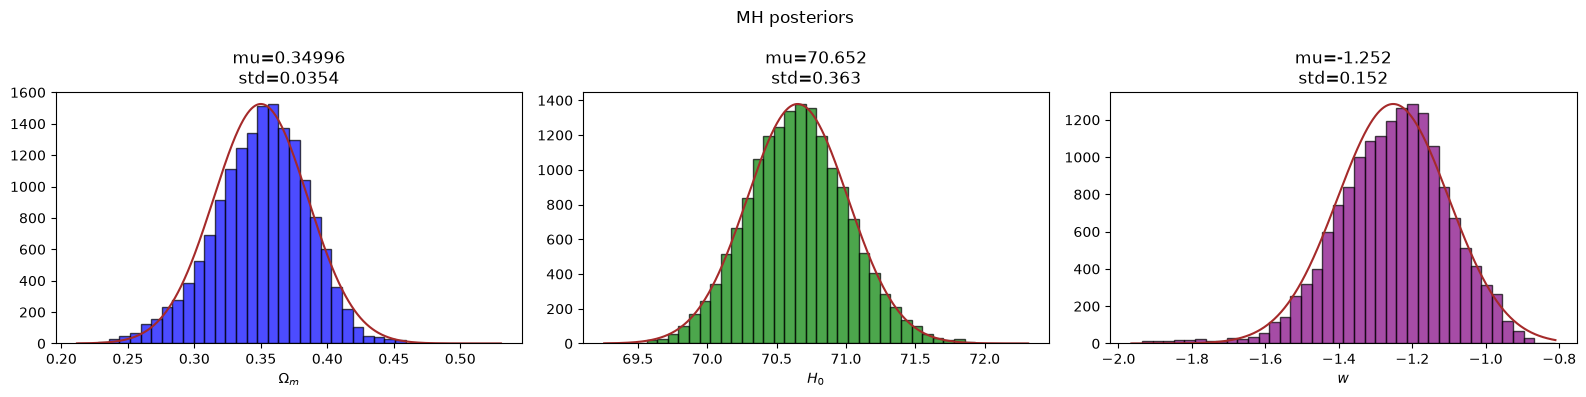

{'Omega_m': (np.float64(0.3499622850066858), np.float64(0.03543887750181929)), 'H0': (np.float64(70.65156667294933), np.float64(0.3631291498268641)), 'w': (np.float64(-1.2520467242964266), np.float64(0.15150714174055266))}


In [14]:
# posterior histograms with Gaussian fits, all three parameters
mh_params = ['Omega_m', 'H0', 'w']
mh_labels = ['$\Omega_m$', '$H_0$', '$w$']
mh_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
mh_fit_results = {}

for ax, pname, label, color in zip(axes, mh_params, mh_labels, mh_colors):
    samples = mh_chain_trimmed[pname]
    mu, std = norm.fit(samples)
    mh_fit_results[pname] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('MH posteriors')
plt.tight_layout()
plt.show()
print(mh_fit_results)

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\2278267152.py:6: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\2278267152.py:7: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_title('MH: $H_0$ vs $\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\2278267152.py:12: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\2278267152.py:13: SyntaxWarning: in

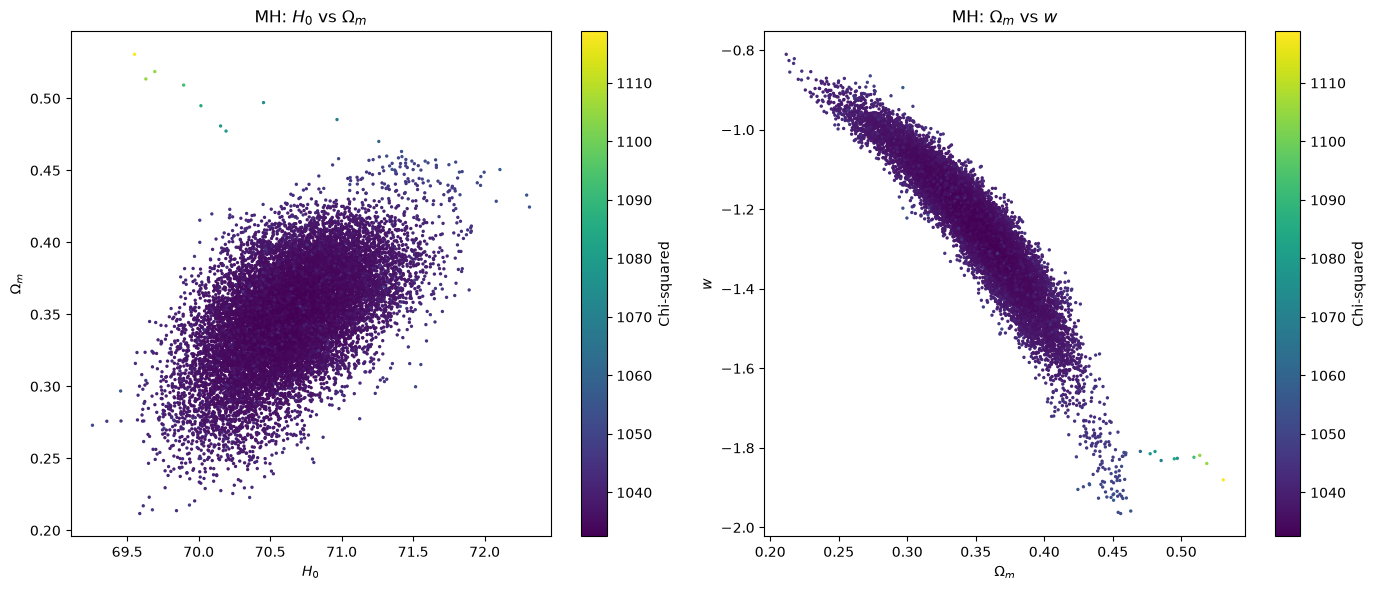

In [15]:
# pairwise sampling pathways colored by chi-squared
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(mh_chain_trimmed['H0'], mh_chain_trimmed['Omega_m'],
                       c=mh_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
axes[0].set_title('MH: $H_0$ vs $\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='Chi-squared')

sc1 = axes[1].scatter(mh_chain_trimmed['Omega_m'], mh_chain_trimmed['w'],
                       c=mh_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
axes[1].set_title('MH: $\Omega_m$ vs $w$')
plt.colorbar(sc1, ax=axes[1], label='Chi-squared')

plt.tight_layout()
plt.show()

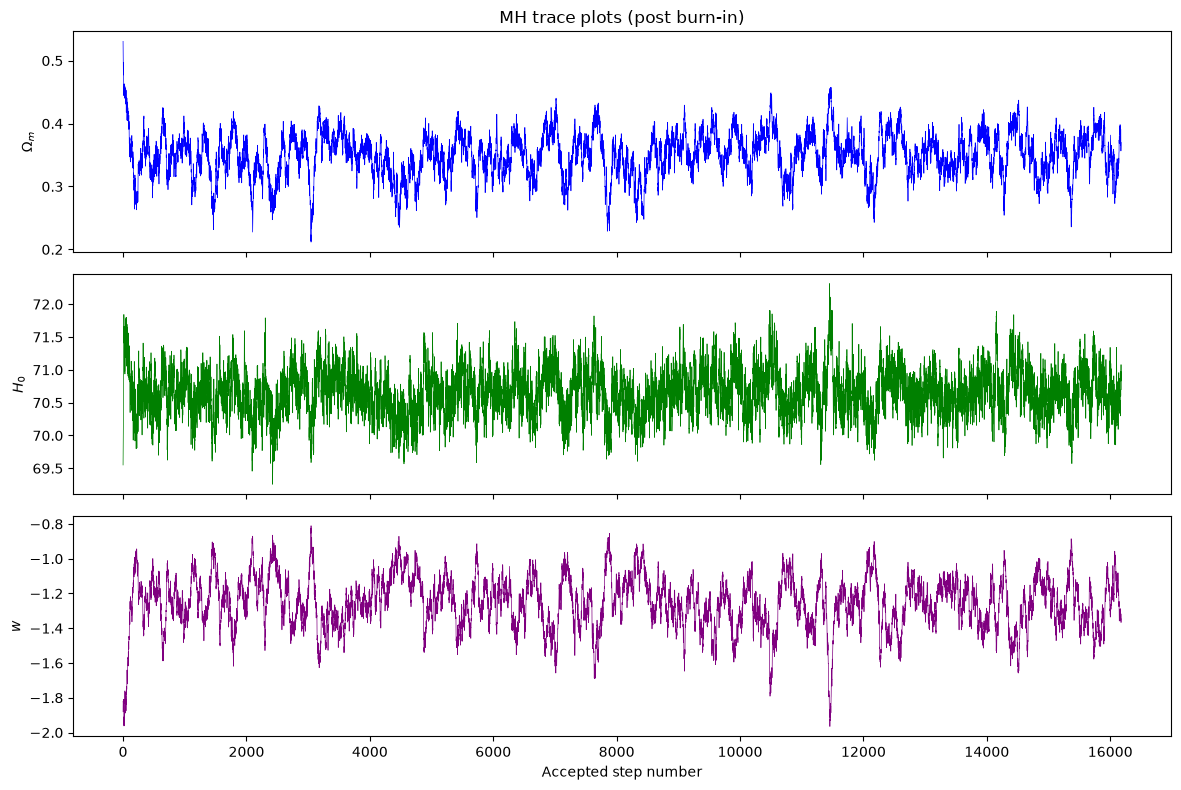

In [16]:
# trace plots for all three parameters
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, pname, label, color in zip(axes, mh_params, mh_labels, mh_colors):
    ax.plot(mh_chain_trimmed[pname], linewidth=0.5, color=color)
    ax.set_ylabel(label)
axes[0].set_title('MH trace plots (post burn-in)')
axes[-1].set_xlabel('Accepted step number')
plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\1523830775.py:5: SyntaxWarning: invalid escape sequence '\O'
  corner.corner(mh_corner_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],


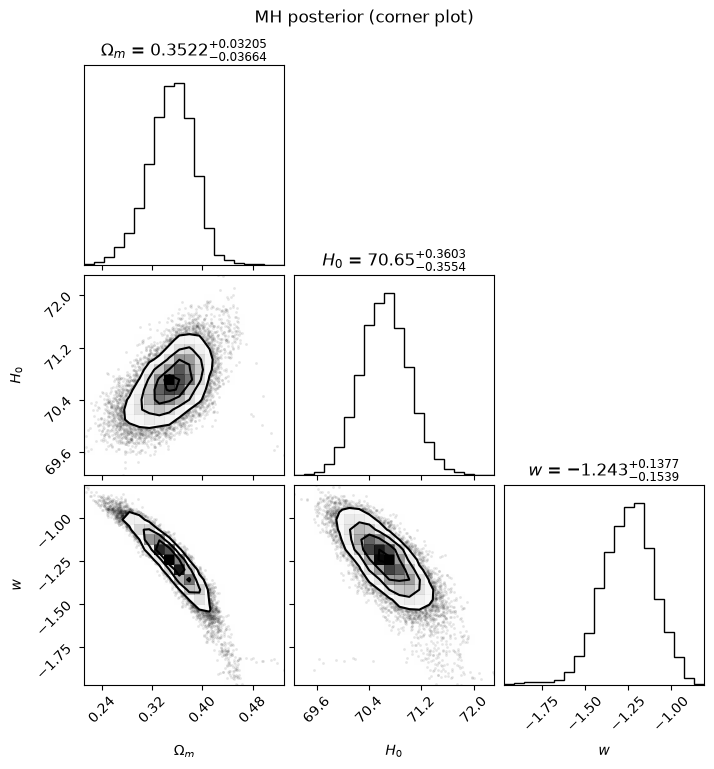

In [17]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (MH)
import corner

mh_corner_samples = mh_chain_trimmed[['Omega_m', 'H0', 'w']].to_numpy()
corner.corner(mh_corner_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('MH posterior (corner plot)', y=1.02)
plt.show()

# Parameter Estimation: emcee Affine-Invariant Ensemble Sampler

Same `log_posterior` likelihood, sampled with `emcee`. Requires `pip install emcee`.

In [18]:
import emcee
import time
import json

n_dim = 3
n_walkers = 15
n_steps = 3300
n_burn = 300

emcee_backend_path = os.path.join(cache_dir, "emcee_chain.h5")   # requires: pip install h5py
emcee_meta_path = os.path.join(cache_dir, "emcee_meta.json")
force_rerun_emcee = False   # set True to ignore the cache and re-sample

emcee_current_settings = {'n_walkers': n_walkers, 'n_steps': n_steps, 'n_dim': n_dim}

emcee_cache_valid = False
if os.path.exists(emcee_backend_path) and os.path.exists(emcee_meta_path) and not force_rerun_emcee:
    with open(emcee_meta_path) as f:
        emcee_cached_settings = json.load(f)
    emcee_cache_valid = (emcee_cached_settings == emcee_current_settings)
    if not emcee_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {emcee_cached_settings}")
        print(f"  current: {emcee_current_settings}")

backend = emcee.backends.HDFBackend(emcee_backend_path)

if emcee_cache_valid:
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, backend=backend)
    print(f"Loaded cached emcee chain from {emcee_backend_path} ({backend.iteration} steps)")

else:
    theta0 = np.array([0.3, 70.0, -1.0])   # (omega_m, H0, w) initial guess
    spread = np.array([0.01, 0.5, 0.05])
    initial_pos = theta0 + spread * np.random.randn(n_walkers, n_dim)
    initial_pos[:, 2] = np.clip(initial_pos[:, 2], param_bounds['w'][0], param_bounds['w'][1])

    backend.reset(n_walkers, n_dim)
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, backend=backend)

    start_time = time.time()
    sampler.run_mcmc(initial_pos, n_steps, progress=True)
    emcee_runtime = time.time() - start_time
    print(f"emcee runtime: {emcee_runtime:.2f} s")

    with open(emcee_meta_path, "w") as f:
        json.dump(emcee_current_settings, f)
    print(f"Saved emcee chain to {emcee_backend_path}")

print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

Loaded cached emcee chain from mcmc_cache_wcdm\emcee_chain.h5 (3300 steps)
Mean acceptance fraction: 0.624


In [19]:
# discard burn-in and flatten walkers into a single sample set
emcee_flat_samples = sampler.get_chain(discard=n_burn, flat=True)
emcee_logpost = sampler.get_log_prob(discard=n_burn, flat=True)

emcee_tau = sampler.get_autocorr_time(quiet=True)
emcee_eff_samples = len(emcee_flat_samples) / np.mean(emcee_tau)
print(f"Autocorrelation time (omega_m, H0, w): {emcee_tau}")
print(f"Effective independent samples: {emcee_eff_samples:.0f}")

Autocorrelation time (omega_m, H0, w): [55.87694587 49.90513573 58.12941856]
Effective independent samples: 824


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3555143378.py:2: SyntaxWarning: invalid escape sequence '\O'
  emcee_labels = ['$\Omega_m$', '$H_0$', '$w$']


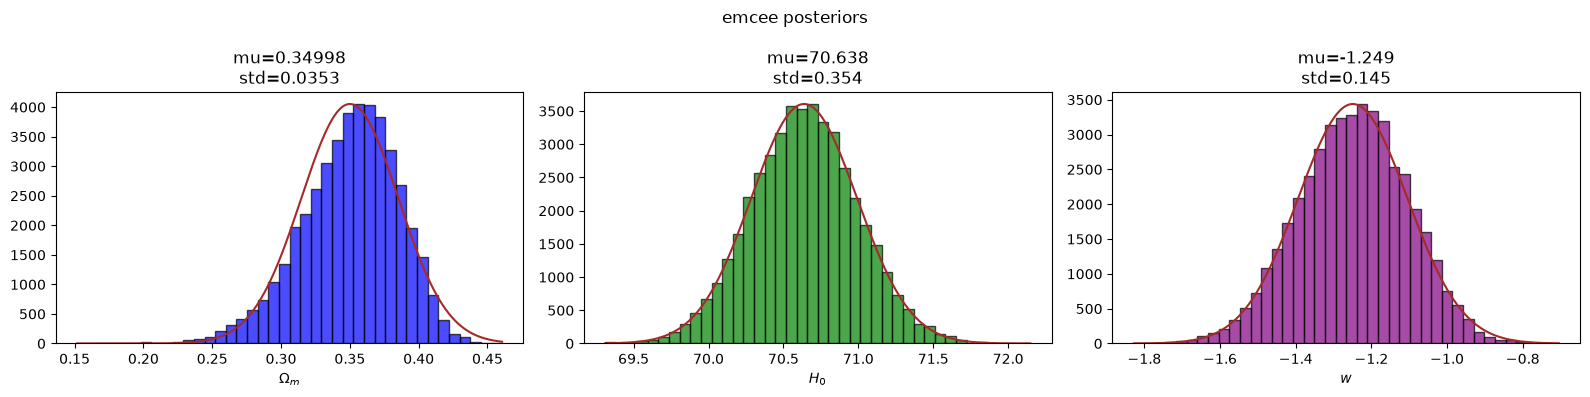

{'$\\Omega_m$': (np.float64(0.3499806098701637), np.float64(0.035272725550462874)), '$H_0$': (np.float64(70.63784409540017), np.float64(0.35360123559116813)), '$w$': (np.float64(-1.249005003428325), np.float64(0.14450138846923868))}


In [20]:
# posterior histograms with Gaussian fits, all three parameters
emcee_labels = ['$\Omega_m$', '$H_0$', '$w$']
emcee_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
emcee_fit_results = {}

for i, (ax, label, color) in enumerate(zip(axes, emcee_labels, emcee_colors)):
    samples = emcee_flat_samples[:, i]
    mu, std = norm.fit(samples)
    emcee_fit_results[label] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('emcee posteriors')
plt.tight_layout()
plt.show()
print(emcee_fit_results)

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3682228564.py:6: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3682228564.py:7: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_title('emcee: $H_0$ vs $\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3682228564.py:12: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3682228564.py:13: SyntaxWarning:

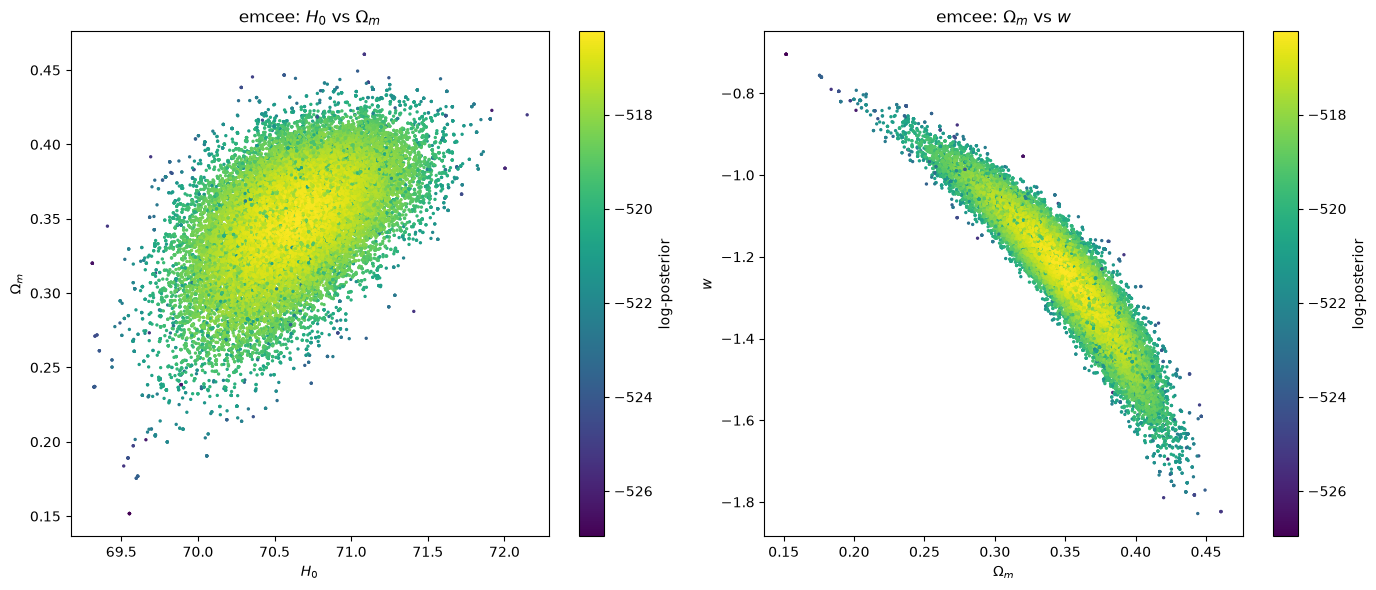

In [21]:
# pairwise sampling pathways colored by log-posterior
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(emcee_flat_samples[:, 1], emcee_flat_samples[:, 0],
                       c=emcee_logpost, cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
axes[0].set_title('emcee: $H_0$ vs $\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='log-posterior')

sc1 = axes[1].scatter(emcee_flat_samples[:, 0], emcee_flat_samples[:, 2],
                       c=emcee_logpost, cmap='viridis', s=2)
axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
axes[1].set_title('emcee: $\Omega_m$ vs $w$')
plt.colorbar(sc1, ax=axes[1], label='log-posterior')

plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3856563758.py:3: SyntaxWarning: invalid escape sequence '\O'
  trace_labels = ['$\Omega_m$', '$H_0$', '$w$']


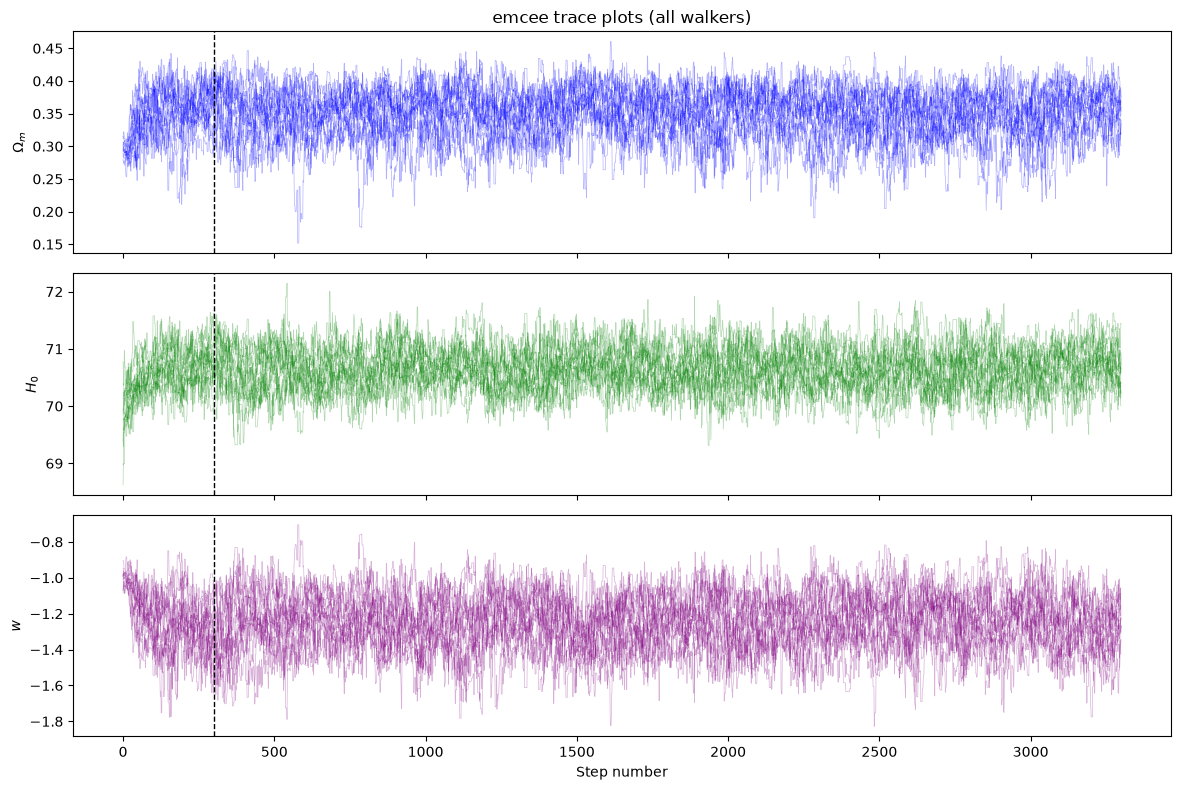

In [22]:
# trace plots for all walkers, all three parameters (before burn-in removal)
full_chain = sampler.get_chain()
trace_labels = ['$\Omega_m$', '$H_0$', '$w$']
trace_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (ax, label, color) in enumerate(zip(axes, trace_labels, trace_colors)):
    ax.plot(full_chain[:, :, i], color=color, alpha=0.3, linewidth=0.5)
    ax.axvline(n_burn, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(label)
axes[0].set_title('emcee trace plots (all walkers)')
axes[-1].set_xlabel('Step number')
plt.tight_layout()
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3934234042.py:2: SyntaxWarning: invalid escape sequence '\O'
  corner.corner(emcee_flat_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],


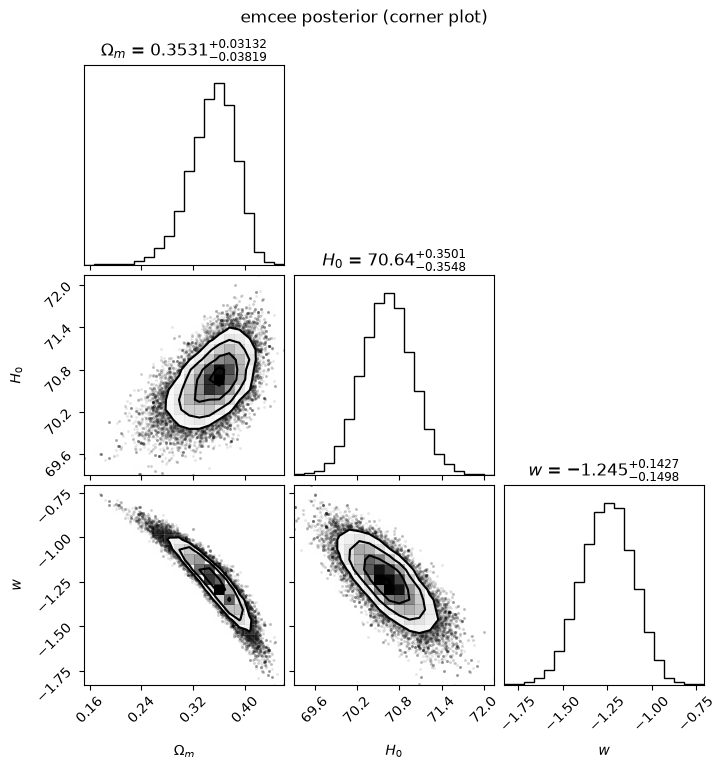

In [23]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (emcee)
corner.corner(emcee_flat_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('emcee posterior (corner plot)', y=1.02)
plt.show()

# Adaptive MCMC (Adaptive Metropolis, Haario et al. 2001)

The plain MH sampler above used a fixed, diagonal step size (`mh_steps`) across all three
parameters — i.e. it implicitly assumed $\Omega_m$, $H_0$, and $w$ are uncorrelated. The MH
corner plot above should show this isn't true (in particular, $\Omega_m$ and $w$ are
typically degenerate for SNe-only fits, similar to the $\Omega_m$-$\Omega_\Lambda$
degeneracy in standard $\Lambda$CDM fits).

Adaptive Metropolis fixes this in two stages:

1. **Seed** the proposal covariance from the pilot MH chain that already ran.
2. **Keep updating** that covariance as the adaptive chain runs, using Haario's scaling
   $C_t = s_d \cdot \text{Cov}(\theta_0, \dots, \theta_t) + s_d\,\epsilon I_d$, with
   $s_d = 2.4^2/d$, $d=3$.

In [24]:
# pilot covariance matrix, estimated from the completed plain-MH chain
pilot_samples = mh_chain_trimmed[['Omega_m', 'H0', 'w']].to_numpy()
pilot_cov = np.cov(pilot_samples, rowvar=False)
pilot_corr = np.corrcoef(pilot_samples, rowvar=False)

print("Pilot covariance matrix (Omega_m, H0, w):")
print(pilot_cov)
print("\nPilot correlation matrix:")
print(pilot_corr)
print(f"\nOmega_m-H0 correlation: {pilot_corr[0, 1]:.3f}")
print(f"Omega_m-w correlation:  {pilot_corr[0, 2]:.3f}")
print(f"H0-w correlation:       {pilot_corr[1, 2]:.3f}")

Pilot covariance matrix (Omega_m, H0, w):
[[ 0.00125599  0.00706524 -0.00500565]
 [ 0.00706524  0.13187093 -0.04146122]
 [-0.00500565 -0.04146122  0.02295583]]

Pilot correlation matrix:
[[ 1.          0.54898298 -0.93222506]
 [ 0.54898298  1.         -0.75356558]
 [-0.93222506 -0.75356558  1.        ]]

Omega_m-H0 correlation: 0.549
Omega_m-w correlation:  -0.932
H0-w correlation:       -0.754


In [25]:
# adaptive MCMC settings
d = 3                          # (omega_m, H0, w)
sd = (2.4**2) / d                # Haario's optimal scaling constant
epsilon = 1e-8                   # covariance regularizer

adapt_start = 300                 # start adapting after this many iterations
adapt_interval = 150               # recompute the covariance every this many iterations
am_n_iterations = 50000

initial_theta = pilot_samples[-1].copy()   # start where the pilot MH chain ended
initial_cov = sd * pilot_cov + sd * epsilon * np.eye(d)

print(f"d={d}, s_d={sd:.3f}")
print(f"Starting point (omega_m, H0, w): {initial_theta}")
print("Initial (seeded) proposal covariance:")
print(initial_cov)

d=3, s_d=1.920
Starting point (omega_m, H0, w): [ 0.36998272 70.69847703 -1.34682316]
Initial (seeded) proposal covariance:
[[ 0.00241152  0.01356526 -0.00961085]
 [ 0.01356526  0.25319221 -0.07960555]
 [-0.00961085 -0.07960555  0.04407522]]


In [26]:
# run the Adaptive Metropolis chain (or load a cached one)
import pickle
import json

am_cache_path = os.path.join(cache_dir, "am_chain.csv")
am_cov_cache_path = os.path.join(cache_dir, "am_cov_snapshots.pkl")
am_meta_path = os.path.join(cache_dir, "am_meta.json")
force_rerun_am = False   # set True to ignore the cache and re-sample

am_current_settings = {
    'n_iterations': am_n_iterations,
    'adapt_start': adapt_start,
    'adapt_interval': adapt_interval,
    'd': d,
}

am_cache_valid = False
if (os.path.exists(am_cache_path) and os.path.exists(am_cov_cache_path)
        and os.path.exists(am_meta_path) and not force_rerun_am):
    with open(am_meta_path) as f:
        am_cached_settings = json.load(f)
    am_cache_valid = (am_cached_settings == am_current_settings)
    if not am_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {am_cached_settings}")
        print(f"  current: {am_current_settings}")

if am_cache_valid:
    am_chain = pd.read_csv(am_cache_path)
    with open(am_cov_cache_path, "rb") as f:
        cov_snapshots = pickle.load(f)
    n_accepted_am = int(am_chain['Accepted'].sum())
    proposal_cov = cov_snapshots[-1][1] if cov_snapshots else initial_cov
    print(f"Loaded cached AM chain from {am_cache_path} ({len(am_chain)} samples)")

else:
    history = list(pilot_samples)  # seed the covariance history with the pilot chain

    am_samples = np.zeros((am_n_iterations, d))
    am_chi2 = np.zeros(am_n_iterations)
    am_accepted = np.zeros(am_n_iterations, dtype=bool)
    cov_snapshots = []  # (iteration, covariance matrix) at each adaptation checkpoint

    theta_curr = initial_theta.copy()
    chi2_curr = chi_squared_wcdm(theta_curr[1], theta_curr[0], theta_curr[2])
    proposal_cov = initial_cov.copy()

    n_accepted_am = 0
    for t in range(am_n_iterations):
        theta_prop = np.random.multivariate_normal(theta_curr, proposal_cov)

        if in_bounds(theta_prop):
            chi2_prop = chi_squared_wcdm(theta_prop[1], theta_prop[0], theta_prop[2])
            accept_prob = min(1.0, np.exp(-(chi2_prop - chi2_curr) / 2))
        else:
            accept_prob = 0.0
            chi2_prop = chi2_curr

        if np.random.uniform(0, 1) < accept_prob:
            theta_curr, chi2_curr = theta_prop, chi2_prop
            n_accepted_am += 1
            am_accepted[t] = True

        am_samples[t] = theta_curr
        am_chi2[t] = chi2_curr
        history.append(theta_curr.copy())

        if t >= adapt_start and t % adapt_interval == 0:
            empirical_cov = np.cov(np.array(history), rowvar=False)
            proposal_cov = sd * empirical_cov + sd * epsilon * np.eye(d)
            cov_snapshots.append((t, empirical_cov.copy()))

    print(f"Adaptive MCMC acceptance fraction: {n_accepted_am / am_n_iterations:.3f}")
    print(f"Number of covariance updates performed: {len(cov_snapshots)}")
    print("\nFinal adapted proposal covariance:")
    print(proposal_cov)

    am_chain = pd.DataFrame(am_samples, columns=['Omega_m', 'H0', 'w'])
    am_chain['Chi_sq'] = am_chi2
    am_chain['Accepted'] = am_accepted
    am_chain.to_csv(am_cache_path, index=False)
    with open(am_cov_cache_path, "wb") as f:
        pickle.dump(cov_snapshots, f)
    with open(am_meta_path, "w") as f:
        json.dump(am_current_settings, f)
    print(f"Saved AM chain to {am_cache_path} and covariance snapshots to {am_cov_cache_path}")

Loaded cached AM chain from mcmc_cache_wcdm\am_chain.csv (50000 samples)


In [27]:
# drop the (short) pre-adaptation burn-in (am_chain is already built, cached or fresh)
am_chain_trimmed = am_chain.iloc[adapt_start:].reset_index(drop=True)
print(f"Samples retained: {len(am_chain_trimmed)} / {len(am_chain)}")
am_chain_trimmed.head()

Samples retained: 49700 / 50000


,Omega_m,H0,w,Chi_sq,Accepted
0,0.32615,70.343132,-1.115061,1033.590029,False
1,0.32615,70.343132,-1.115061,1033.590029,False
2,0.32615,70.343132,-1.115061,1033.590029,False
3,0.32615,70.343132,-1.115061,1033.590029,False
4,0.32615,70.343132,-1.115061,1033.590029,False


<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\4043999614.py:3: SyntaxWarning: invalid escape sequence '\O'
  am_labels = ['$\Omega_m$', '$H_0$', '$w$']


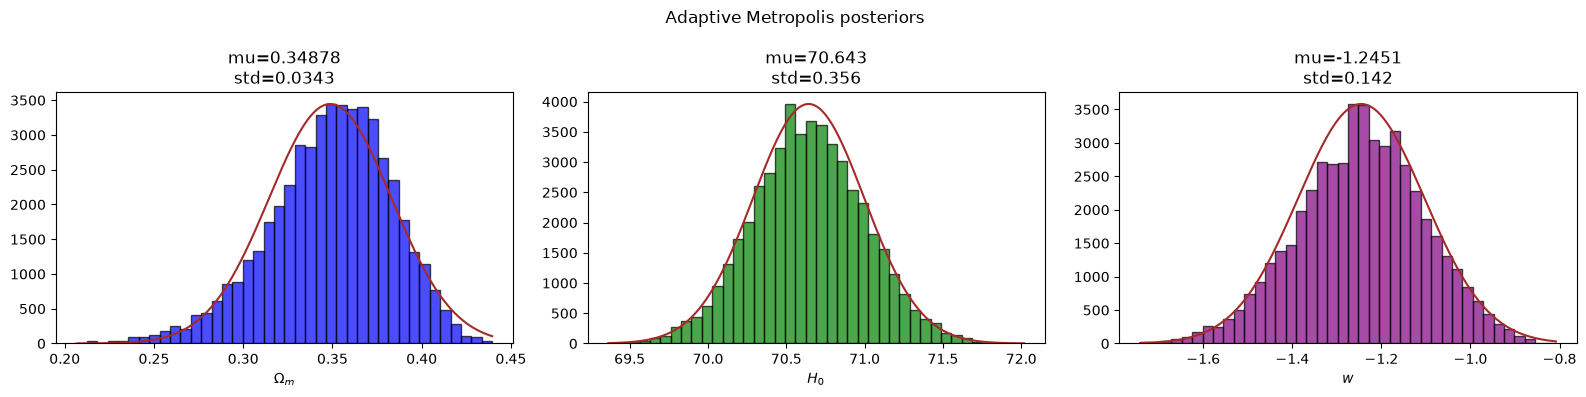

{'Omega_m': (np.float64(0.34878458476479657), np.float64(0.03433152088428476)), 'H0': (np.float64(70.64254589480423), np.float64(0.3555646606617582)), 'w': (np.float64(-1.2451341510688791), np.float64(0.14191025631724727))}


In [28]:
# posterior histograms with Gaussian fits, all three parameters (Adaptive Metropolis)
am_params = ['Omega_m', 'H0', 'w']
am_labels = ['$\Omega_m$', '$H_0$', '$w$']
am_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
am_fit_results = {}

for ax, pname, label, color in zip(axes, am_params, am_labels, am_colors):
    samples = am_chain_trimmed[pname]
    mu, std = norm.fit(samples)
    am_fit_results[pname] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('Adaptive Metropolis posteriors')
plt.tight_layout()
plt.show()
print(am_fit_results)

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\790298907.py:6: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\790298907.py:7: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_title('AM: $H_0$ vs $\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\790298907.py:12: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\790298907.py:13: SyntaxWarning: invali

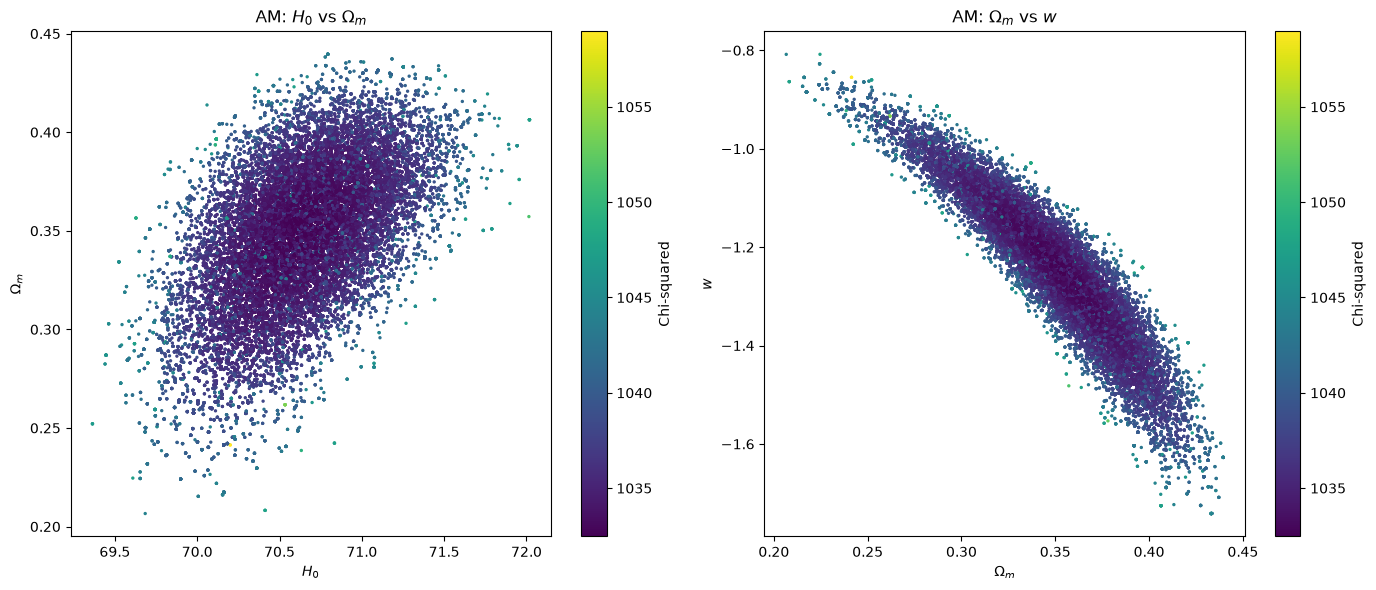

In [29]:
# pairwise sampling pathways colored by chi-squared (Adaptive Metropolis)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(am_chain_trimmed['H0'], am_chain_trimmed['Omega_m'],
                       c=am_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
axes[0].set_title('AM: $H_0$ vs $\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='Chi-squared')

sc1 = axes[1].scatter(am_chain_trimmed['Omega_m'], am_chain_trimmed['w'],
                       c=am_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$w$')
axes[1].set_title('AM: $\Omega_m$ vs $w$')
plt.colorbar(sc1, ax=axes[1], label='Chi-squared')

plt.tight_layout()
plt.show()

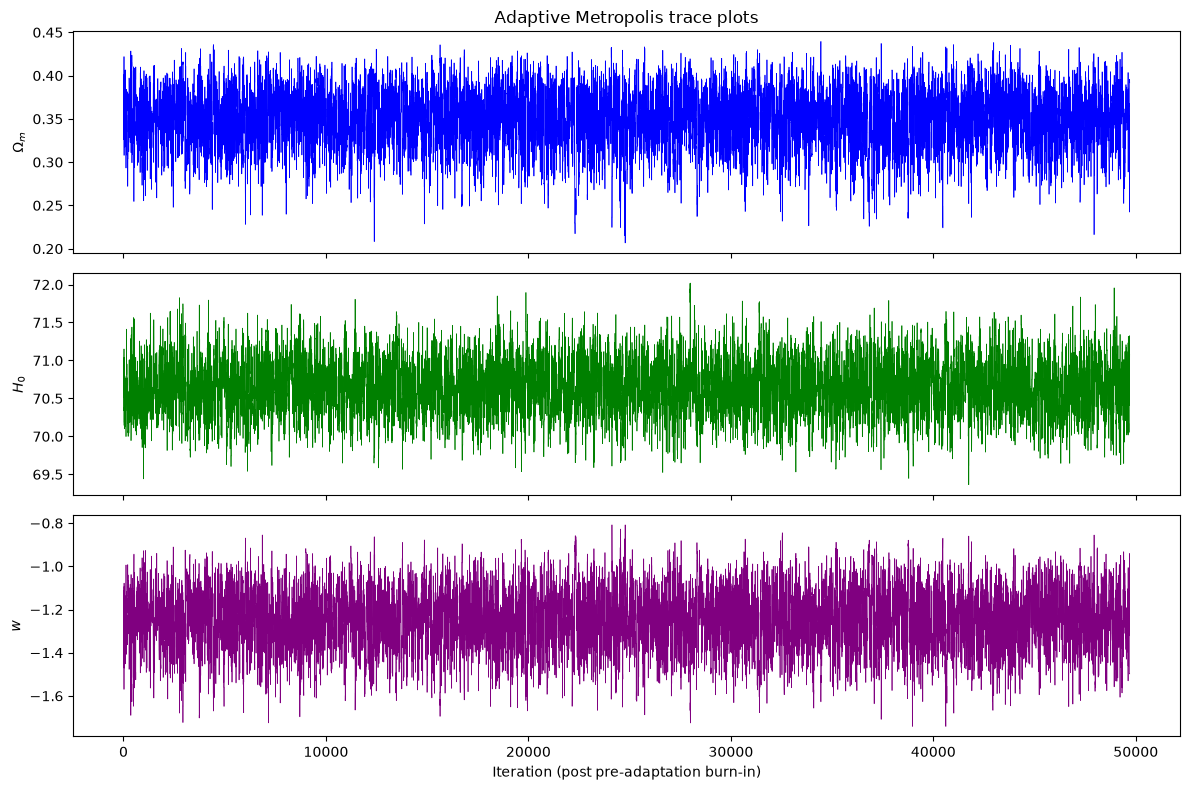

In [30]:
# trace plots for all three parameters (Adaptive Metropolis)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, pname, label, color in zip(axes, am_params, am_labels, am_colors):
    ax.plot(am_chain_trimmed[pname], linewidth=0.5, color=color)
    ax.set_ylabel(label)
axes[0].set_title('Adaptive Metropolis trace plots')
axes[-1].set_xlabel('Iteration (post pre-adaptation burn-in)')
plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\1074159823.py:3: SyntaxWarning: invalid escape sequence '\O'
  corner.corner(am_corner_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],


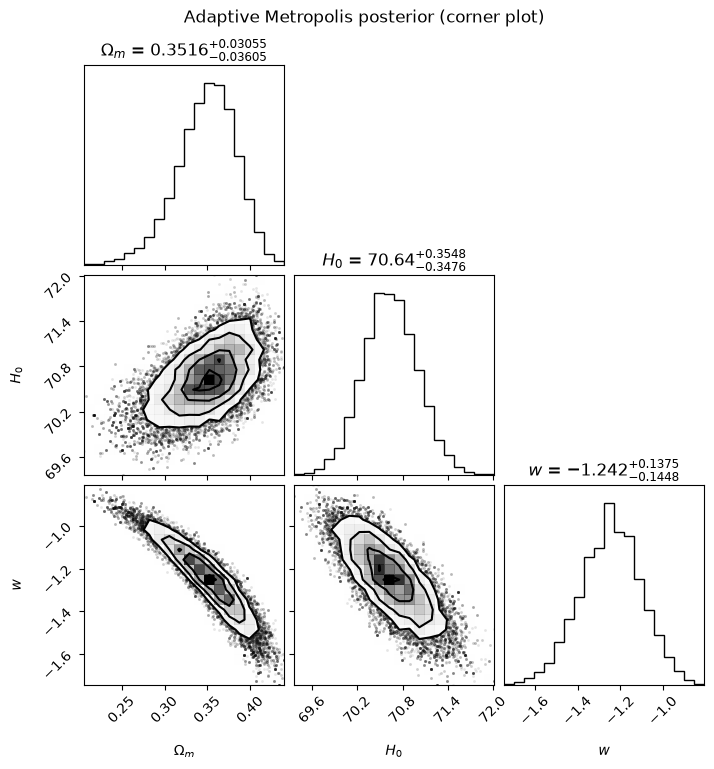

In [31]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (Adaptive Metropolis)
am_corner_samples = am_chain_trimmed[['Omega_m', 'H0', 'w']].to_numpy()
corner.corner(am_corner_samples, labels=['$\Omega_m$', '$H_0$', '$w$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('Adaptive Metropolis posterior (corner plot)', y=1.02)
plt.show()

## Covariance Evolution

How the three pairwise correlations ($\Omega_m$-$H_0$, $\Omega_m$-$w$, $H_0$-$w$) moved as
the AM chain learned the posterior's shape, compared against the fixed pilot-chain values.

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\1073584845.py:13: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(snap_iters, snap_corr_om_H0, label='$\Omega_m$-$H_0$', color='blue')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\1073584845.py:14: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(snap_iters, snap_corr_om_w, label='$\Omega_m$-$w$', color='purple')


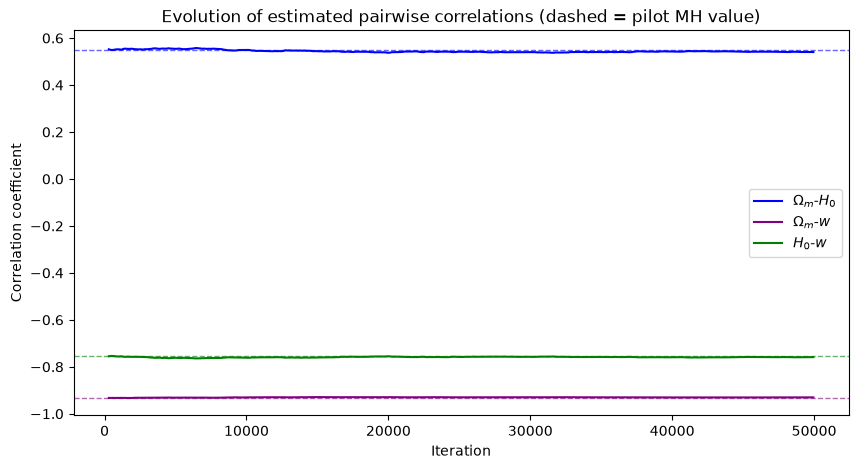

Pilot correlations    -> om-H0: 0.549, om-w: -0.932, H0-w: -0.754
Final AM correlations -> om-H0: 0.540, om-w: -0.930, H0-w: -0.759


In [32]:
snap_iters = [s[0] for s in cov_snapshots]


def corr_from_cov(cov, i, j):
    return cov[i, j] / np.sqrt(cov[i, i] * cov[j, j])


snap_corr_om_H0 = [corr_from_cov(s[1], 0, 1) for s in cov_snapshots]
snap_corr_om_w = [corr_from_cov(s[1], 0, 2) for s in cov_snapshots]
snap_corr_H0_w = [corr_from_cov(s[1], 1, 2) for s in cov_snapshots]

plt.figure(figsize=(10, 5))
plt.plot(snap_iters, snap_corr_om_H0, label='$\Omega_m$-$H_0$', color='blue')
plt.plot(snap_iters, snap_corr_om_w, label='$\Omega_m$-$w$', color='purple')
plt.plot(snap_iters, snap_corr_H0_w, label='$H_0$-$w$', color='green')

plt.axhline(pilot_corr[0, 1], color='blue', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(pilot_corr[0, 2], color='purple', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(pilot_corr[1, 2], color='green', linestyle='--', linewidth=1, alpha=0.6)

plt.xlabel('Iteration')
plt.ylabel('Correlation coefficient')
plt.title('Evolution of estimated pairwise correlations (dashed = pilot MH value)')
plt.legend()
plt.show()

print(f"Pilot correlations    -> om-H0: {pilot_corr[0,1]:.3f}, om-w: {pilot_corr[0,2]:.3f}, H0-w: {pilot_corr[1,2]:.3f}")
print(f"Final AM correlations -> om-H0: {snap_corr_om_H0[-1]:.3f}, om-w: {snap_corr_om_w[-1]:.3f}, H0-w: {snap_corr_H0_w[-1]:.3f}")

# Comparison: MH vs emcee vs Adaptive Metropolis

Effective-sample counts computed the same way for all three chains — via
`emcee.autocorr.integrated_time` on each chain's own samples — so MH's number isn't
inflated by ignoring its autocorrelation.

In [33]:
# properly-corrected effective sample sizes for the two random-walk-style chains
mh_accept_frac = n_accepted / mh_n_iterations
emcee_accept_frac = np.mean(sampler.acceptance_fraction)

mh_tau = emcee.autocorr.integrated_time(
    mh_chain_trimmed[['Omega_m', 'H0', 'w']].to_numpy(), quiet=True)
mh_eff_samples_true = len(mh_chain_trimmed) / np.mean(mh_tau)

am_tau = emcee.autocorr.integrated_time(
    am_chain_trimmed[['Omega_m', 'H0', 'w']].to_numpy(), quiet=True)
am_eff_samples_true = len(am_chain_trimmed) / np.mean(am_tau)
am_accept_frac = n_accepted_am / am_n_iterations

print(f"MH autocorrelation time (omega_m, H0, w): {mh_tau}  ->  N_eff = {mh_eff_samples_true:.0f}")
print(f"AM autocorrelation time (omega_m, H0, w): {am_tau}  ->  N_eff = {am_eff_samples_true:.0f}")
print(f"emcee autocorrelation time (omega_m, H0, w): {emcee_tau}  ->  N_eff = {emcee_eff_samples:.0f}")

MH autocorrelation time (omega_m, H0, w): [74.20732905]  ->  N_eff = 218
AM autocorrelation time (omega_m, H0, w): [17.79764468]  ->  N_eff = 2793
emcee autocorrelation time (omega_m, H0, w): [55.87694587 49.90513573 58.12941856]  ->  N_eff = 824


In [34]:
# three-way comparison table
mh_mu_om, mh_std_om = mh_fit_results['Omega_m']
mh_mu_H0, mh_std_H0 = mh_fit_results['H0']
mh_mu_w, mh_std_w = mh_fit_results['w']

emcee_mu_om, emcee_std_om = emcee_fit_results['$\Omega_m$']
emcee_mu_H0, emcee_std_H0 = emcee_fit_results['$H_0$']
emcee_mu_w, emcee_std_w = emcee_fit_results['$w$']

am_mu_om, am_std_om = am_fit_results['Omega_m']
am_mu_H0, am_std_H0 = am_fit_results['H0']
am_mu_w, am_std_w = am_fit_results['w']

three_way_table = pd.DataFrame({
    'Metric': [
        'Omega_m estimate (mean)',
        'Omega_m std',
        'H0 estimate (mean)',
        'H0 std',
        'w estimate (mean)',
        'w std',
        'Total samples drawn',
        'Acceptance fraction',
        'Autocorrelation time (avg)',
        'Effective independent samples',
        'N_eff per 1000 likelihood calls',
        'Proposal shape',
        'Needs manual tuning',
        'Parallelizable across chains',
        'Built-in convergence diagnostics',
    ],
    'Metropolis-Hastings': [
        f'{mh_mu_om:.4f}', f'{mh_std_om:.4f}',
        f'{mh_mu_H0:.3f}', f'{mh_std_H0:.3f}',
        f'{mh_mu_w:.4f}', f'{mh_std_w:.4f}',
        mh_n_iterations, f'{mh_accept_frac:.3f}',
        f'{np.mean(mh_tau):.1f}', f'{mh_eff_samples_true:.0f}',
        f'{1000 * mh_eff_samples_true / mh_n_iterations:.2f}',
        'Fixed, diagonal (uncorrelated)', 'Yes (3 step sizes, bounds)',
        'No (single chain)', 'No (manual burn-in cut)',
    ],
    'emcee (ensemble)': [
        f'{emcee_mu_om:.4f}', f'{emcee_std_om:.4f}',
        f'{emcee_mu_H0:.3f}', f'{emcee_std_H0:.3f}',
        f'{emcee_mu_w:.4f}', f'{emcee_std_w:.4f}',
        n_walkers * n_steps, f'{emcee_accept_frac:.3f}',
        f'{np.mean(emcee_tau):.1f}', f'{emcee_eff_samples:.0f}',
        f'{1000 * emcee_eff_samples / (n_walkers * n_steps):.2f}',
        'Self-tuning (ensemble spread)', 'No (self-tuning)',
        'Yes (walkers)', 'Yes (autocorr time tau)',
    ],
    'Adaptive Metropolis': [
        f'{am_mu_om:.4f}', f'{am_std_om:.4f}',
        f'{am_mu_H0:.3f}', f'{am_std_H0:.3f}',
        f'{am_mu_w:.4f}', f'{am_std_w:.4f}',
        am_n_iterations, f'{am_accept_frac:.3f}',
        f'{np.mean(am_tau):.1f}', f'{am_eff_samples_true:.0f}',
        f'{1000 * am_eff_samples_true / am_n_iterations:.2f}',
        'Learned covariance (updates online)', 'Only initial seed (then self-tuning)',
        'No (single chain)', 'Partial (correlation evolution plot, no tau built in)',
    ],
})

three_way_table

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_35600\3493182564.py:6: SyntaxWarning: invalid escape sequence '\O'
  emcee_mu_om, emcee_std_om = emcee_fit_results['$\Omega_m$']


,Metric,Metropolis-Hastings,emcee (ensemble),Adaptive Metropolis
0,Omega_m estimate (mean),0.3500,0.3500,0.3488
1,Omega_m std,0.0354,0.0353,0.0343
2,H0 estimate (mean),70.652,70.638,70.643
3,H0 std,0.363,0.354,0.356
4,w estimate (mean),-1.2520,-1.2490,-1.2451
5,w std,0.1515,0.1445,0.1419
6,Total samples drawn,50000,49500,50000
7,Acceptance fraction,0.324,0.624,0.246
8,Autocorrelation time (avg),74.2,54.6,17.8
9,Effective independent samples,218,824,2793


**How to read the table:**

- **Estimate & std** should broadly agree across all three if each has converged.
- **w** is the parameter to watch here: it's strongly degenerate with $\Omega_m$ for SNe-only
  fits (the classic "geometric degeneracy" — many $(\Omega_m, w)$ pairs give nearly the same
  luminosity distance curve), so expect an elongated, tilted $\Omega_m$-$w$ panel in every
  corner plot above. This is exactly the situation Adaptive Metropolis is designed to handle
  better than plain MH, and where emcee's ensemble should have the clearest advantage.
- **N_eff per 1000 likelihood calls** is the fairest efficiency comparison — it normalizes
  out MH/AM making 1 likelihood call per iteration vs emcee's `n_walkers` calls per iteration.
- If the recovered $w$ posterior sits close to $-1$ with a reasonably tight width, that is
  consistent with $\Lambda$CDM (no evidence for evolving dark energy from this dataset alone);
  a wide or off-center $w$ posterior is more likely to reflect the $\Omega_m$-$w$ degeneracy
  than a genuine detection of $w \neq -1$ — this is a known limitation of SNe-only constraints,
  not a bug in the sampler.

## Styled Posterior Corner Plots (2σ & 3σ contours only)

Separate corner plot per sampler, styled like a likelihood-contour figure: filled
2σ/3σ regions only (no 1σ, no raw scatter points, smoothed contours/marginals).
The original per-sampler corner plots earlier in the notebook are left as-is —
these are additional, differently-styled versions, one per method (not overlaid).

In [ ]:
# Metropolis-Hastings: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    mh_corner_samples,
    labels=['$\\Omega_m$', '$H_0$', '$w$'],
    color='crimson',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Metropolis-Hastings: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# emcee: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    emcee_flat_samples,
    labels=['$\\Omega_m$', '$H_0$', '$w$'],
    color='royalblue',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('emcee: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# Adaptive Metropolis: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    am_corner_samples,
    labels=['$\\Omega_m$', '$H_0$', '$w$'],
    color='purple',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Adaptive Metropolis: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()
